In [47]:
import helpers
import importlib
from matplotlib.ticker import ScalarFormatter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
case_df = pd.read_excel("cases.xlsx")
case_df.head()

,case,solution_method,time_scheme,conv_scheme,RE,N,DX,DT_MAX,DT,CFL,URFP,URFU,diverging_factor,IT,clock_time,colour,compare_diff,plot,Coldumn3,Time (min)
0,1,EFSM,1,UDS,1000,16,0.062500,0.062500,0.1500,2.400,NaN,-1.0,0.2000,260.0,0.247447,C0,16.666667,25.0,10.4000,0.004124
1,2,EFSM,1,UDS,1000,32,0.031250,0.031250,0.0500,1.600,NaN,-1.0,0.1000,860.0,3.887910,C0,50.000000,100.0,8.6000,0.064799
2,3,EFSM,1,UDS,1000,64,0.015625,0.015625,0.0150,0.960,NaN,-1.0,0.0200,3322.0,44.980831,C0,166.666667,250.0,13.2880,0.749681
3,4,EFSM,1,UDS,1000,128,0.007812,0.007812,0.0050,0.640,NaN,-1.0,0.0100,11952.0,377.196014,C0,500.000000,1000.0,11.9520,6.286600
4,5,EFSM,1,UDS,1000,256,0.003906,0.003906,0.0015,0.384,NaN,-1.0,0.0025,43836.0,3393.875980,C1,1666.666667,5000.0,8.7672,56.564600


In [48]:
simple_cases = [
    26,27,28,29, 30
]
efsm_cases = [
    1,2,3,4,5
              ]

In [49]:
case_df_slice=case_df[case_df["case"].isin(simple_cases+efsm_cases)]
case_df_slice

,case,solution_method,time_scheme,conv_scheme,RE,N,DX,DT_MAX,DT,CFL,URFP,URFU,diverging_factor,IT,clock_time,colour,compare_diff,plot,Coldumn3,Time (min)
0,1,EFSM,1,UDS,1000,16,0.062500,0.062500,0.1500,2.400,NaN,-1.000,0.2000,260.0,0.247447,C0,16.666667,25.0,10.4000,0.004124
1,2,EFSM,1,UDS,1000,32,0.031250,0.031250,0.0500,1.600,NaN,-1.000,0.1000,860.0,3.887910,C0,50.000000,100.0,8.6000,0.064799
2,3,EFSM,1,UDS,1000,64,0.015625,0.015625,0.0150,0.960,NaN,-1.000,0.0200,3322.0,44.980831,C0,166.666667,250.0,13.2880,0.749681
3,4,EFSM,1,UDS,1000,128,0.007812,0.007812,0.0050,0.640,NaN,-1.000,0.0100,11952.0,377.196014,C0,500.000000,1000.0,11.9520,6.286600
4,5,EFSM,1,UDS,1000,256,0.003906,0.003906,0.0015,0.384,NaN,-1.000,0.0025,43836.0,3393.875980,C1,1666.666667,5000.0,8.7672,56.564600
25,26,SIMPLE,-1,UDS,1000,16,0.062500,-1.000000,-1.0000,-1.000,0.3,0.850,NaN,294.0,0.076144,C3,-2.500000,NaN,NaN,0.001269
26,27,SIMPLE,-1,UDS,1000,32,0.031250,-1.000000,-1.0000,-1.000,0.3,0.730,NaN,427.0,0.314401,NaN,-2.500000,NaN,NaN,0.005240
27,28,SIMPLE,-1,UDS,1000,64,0.015625,-1.000000,-1.0000,-1.000,0.3,0.740,NaN,933.0,2.711655,NaN,-2.500000,NaN,NaN,0.045194
28,29,SIMPLE,-1,UDS,1000,128,0.007812,-1.000000,-1.0000,-1.000,0.3,0.999,NaN,1865.0,21.054308,NaN,-2.500000,NaN,NaN,0.350905
29,30,SIMPLE,-1,UDS,1000,256,0.003906,-1.000000,-1.0000,-1.000,0.3,0.700,NaN,7290.0,421.734253,NaN,-2.500000,NaN,NaN,7.028904


In [50]:
groups = [16, 32, 64, 128]
group_labels = ["16", "32", "64", "128"]

In [55]:
# CaseManager([59,60,61,62,63, 64,65,66], solution_method="SIMPLE", N=64, conv_scheme="uds", RE=1000)
importlib.reload(helpers)
CavityCase = helpers.CavityCase
CaseManager = helpers.CaseManager

simple_manager = CaseManager([26,27,28,29,30], solution_method="SIMPLE", conv_scheme="uds", RE=1000)
efsm_manager = CaseManager([1,2,3,4,5], solution_method="EFSM", conv_scheme="uds", RE=1000)
# CavityCase(2).res_df

In [57]:
simple_manager.compare_meta()
efsm_manager.compare_meta()

,solution_method,conv_scheme,RE,N,time_scheme,DT,clock_time,IT,sum_N,total_outer_iterations,total_inner_iterations,avg_inner_per_outer
1,fs,uds,1000.0,16,1,0.1500,0.242388,260,705,260,14100,54.230769
2,fs,uds,1000.0,32,1,0.0500,3.887910,860,3539,860,70780,82.302326
3,fs,uds,1000.0,64,1,0.0150,44.980831,3322,9829,3322,196580,59.175196
4,fs,uds,1000.0,128,1,0.0050,377.196014,11952,20565,11952,411300,34.412651
5,fs,uds,1000.0,256,1,0.0015,3393.875980,43836,51546,43836,1030920,23.517657


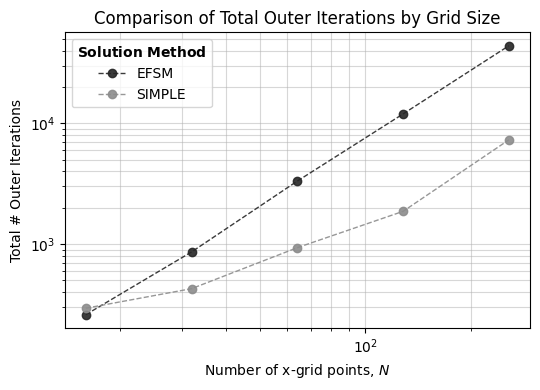

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

df = case_df_slice

solvers = ["EFSM", "SIMPLE"]

labels = {
    "EFSM": r"$2^{nd}$ order diffusion",
    "SIMPLE": r"$4^{th}$ order diffusion"
}

colors = {
    "EFSM": "0.15",
    "SIMPLE": "0.55",
}

# Get grid sizes
groups = sorted(df["N"].unique())

fig, ax = plt.subplots(figsize=(5.5,4))

for solver in solvers:
    subset = df[df["solution_method"] == solver]
    subset = subset.sort_values(by="N")

    # Align values with groups
    x_vals = []
    y_vals = []

    for N in groups:
        row = subset[subset["N"] == N]
        if len(row) > 0:
            x_vals.append(N)
            y_vals.append(row["IT"].values[0])

    ax.plot(
        x_vals, y_vals,
        marker='o',
        linewidth=1,
        linestyle='dashed',
        label=solver,
        color=colors[solver],
        alpha=0.9
    )

# Formatting
ax.set_xlabel(r"Number of x-grid points, $N$")
ax.set_ylabel("Total # Outer Iterations")
ax.set_title("Comparison of Total Outer Iterations by Grid Size")
ax.legend(title=r"$\bf{Solution\ Method}$")

ax.set_axisbelow(True)
ax.grid(True, which='major', axis='both', alpha=0.5)

ax.grid(which='minor', alpha=0.5)
# Optional: scientific notation for y-axis
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax.set_xscale('log')
ax.set_yscale('log')
fig.tight_layout()


plt.show()

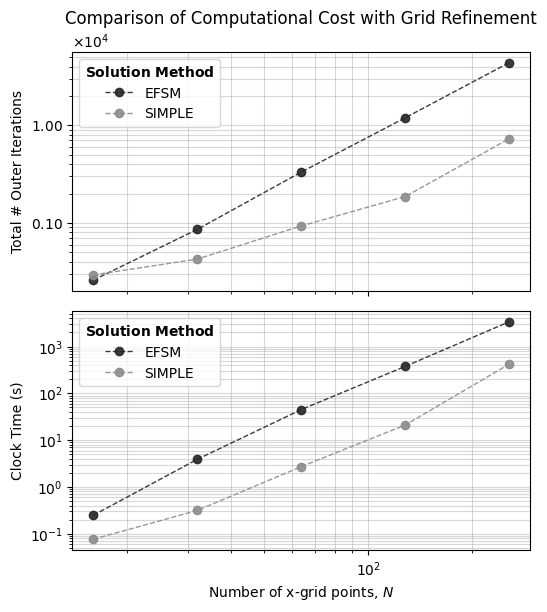

In [53]:


df = case_df_slice

solvers = ["EFSM", "SIMPLE"]

labels = {
    "EFSM": r"$2^{nd}$ order diffusion",
    "SIMPLE": r"$4^{th}$ order diffusion"
}

colors = {
    "EFSM": "0.15",
    "SIMPLE": "0.55",
}

# Get grid sizes
groups = sorted(df["N"].unique())

fig, axes = plt.subplots(2,1, figsize=(5.5,6), sharex=True)

for i,col in enumerate(['IT', 'clock_time']):
    ax=axes[i]
    for solver in solvers:
        subset = df[df["solution_method"] == solver]
        subset = subset.sort_values(by="N")

        # Align values with groups
        x_vals = []
        y_vals = []

        for N in groups:
            row = subset[subset["N"] == N]
            if len(row) > 0:
                x_vals.append(N)
                y_vals.append(row[col].values[0])

        ax.plot(
            x_vals, y_vals,
            marker='o',
            linewidth=1,
            linestyle='dashed',
            label=solver,
            color=colors[solver],
            alpha=0.9
        )

# Formatting
    ax.legend(title=r"$\bf{Solution\ Method}$")

    ax.set_axisbelow(True)
    ax.grid(True, which='major', axis='both', alpha=0.5)

    ax.grid(which='minor', alpha=0.5)
    # Optional: scientific notation for y-axis
    axes[0].yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    axes[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax.set_xscale('log')
    ax.set_yscale('log')
axes[1].set_xlabel(r"Number of x-grid points, $N$")
axes[0].set_ylabel("Total # Outer Iterations")
axes[1].set_ylabel("Clock Time (s)")
fig.tight_layout()

axes[0].set_title("Comparison of Computational Cost with Grid Refinement")
plt.show()

ValueError: ('Lengths must match to compare', (10,), (2,))

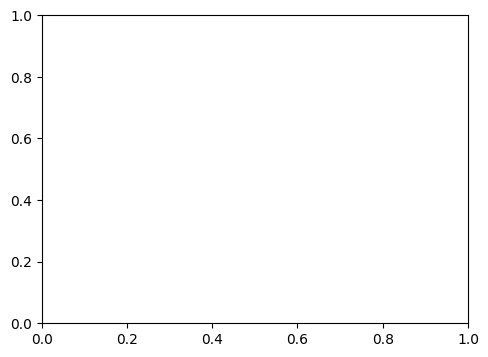

In [54]:

# case_df_slice = case_df[(case_df['URFU']>=0)& (case_df['plot']>0) & (case_df['conv_scheme']=="QUICK")]
# case_df_slice['label']=(case_df['conv_scheme'].astype(str) +case_df['diff_scheme'].astype(int).astype(str)).str.lower()
case_df.head()
# Define groups
df = case_df_slice
groups = [(400,40),(1000,40),(400,80),(1000,80)]
group_labels = ["Case 5:\nRe=400,\n40$\\times$40 grid","Case 6:\nRe=1000,\n40$\\times$40 grid","Case 7:\nRe=400,\n80$\\times$80 grid","Case 8:\nRe=1000,\n80$\\times$80 grid",]

solver = ["EFSM", "SIMPLE"]
labels={
    "EFSM": r"$2^{nd}$ order diffusion",
    "SIMPLE": r"$4^{th}$ order diffusion"
}
colors = {
    "EFSM":   "0.15",   # light gray
    "SIMPLE":"0.55",   # medium-light gray
}
alpha_values = {
    "EFSM": 1.0,
    "SIMPLE": 0.6
}

hatches = {"EFSM":"", "SIMPLE":""}  # diffusion order

fig, ax = plt.subplots(figsize=(5.5,4))
bar_width = 0.25
x = np.arange(len(groups))

for i, scheme in enumerate(solver):
    offsets = x + (i - 0.5)*bar_width
    subset = df[df["solution_method"] == solver]
    heights = []
    hatch_list = []
    for (Re,N) in groups:
        row = subset[(subset["RE"]==Re) & (subset["N"]==N)]
        if len(row)==0:
            heights.append(0)
            hatch_list.append("")
        else:
            heights.append(row["IT"].values[0])
            hatch_list.append(hatches[row["solution_method"].values[0]])
    print(heights)
    bars = ax.bar(offsets, heights, bar_width, label=labels[scheme], color='C3', alpha=alpha_values[scheme], linewidth=0.1)
    # Apply hatching for diffusion order
    for bar, hatch in zip(bars, hatch_list):
        bar.set_hatch(hatch)
ax.set_xticks(x)
ax.set_xticklabels(group_labels)
ax.set_ylabel("# Iterations")
ax.set_title("Comparison of # Iterations by Diffusion Scheme, Grid, Re")
ax.legend(title=r"$\bf{Diff.\ Scheme}$")
ax.set_axisbelow(True)
ax.grid(True, axis='y',  alpha=0.5)

fig.tight_layout()
fig.savefig("../figures/diff_iterations_comparison.png", dpi=300)

